<div style="text-align: center;">
<h1 style="font-size:2rem;color:purple;">Clustering and Anomaly Detection in Smart City Management

### 1. Part 1: <u>K-Means Clustering for Transportation Optimization</u>

Task:  Implement K-means clustering algorithm to group similar traffic patterns

#### 1.1. Import Required Libraries and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

current_dir = Path.cwd()
image_dir = current_dir.parent / "images" if current_dir.name == "notebooks" else current_dir / "images"
image_dir.mkdir(parents=True, exist_ok=True)

# Load traffic data
traffic_data = pd.read_csv("../data/traffic_data.csv").values

#### 1.2 Implementation

In [2]:
# Helper function to find the closest centroids
def find_closest_centroids(X, centroids):
    idx = np.zeros(X.shape[0], dtype=int)
    for i in range(X.shape[0]):
        distances = np.linalg.norm(X[i] - centroids, axis=1)
        idx[i] = np.argmin(distances)
    return idx

# Helper function to compute new centroids
def compute_centroids(X, idx, K):
    centroids = np.zeros((K, X.shape[1]))
    for k in range(K):
        points = X[idx == k]
        centroids[k] = np.mean(points, axis=0)
    return centroids

# Main K-means functions
def run_kmeans(X, initial_centroids, max_iters):
    centroids = initial_centroids
    for _ in range(max_iters):
        idx = find_closest_centroids(X, centroids)
        centroids = compute_centroids(X, idx, centroids.shape[0])
    return centroids, idx

# Initialize centroids (you can  modify this function for dynamic initialization)
def initialize_centroids(X, K):
    return X[np.random.choice(X.shape[0], K, replace=False)]

# Parameters
# Number of clusters
K = 3
max_iters = 100

# Run K-means
initial_centroids = initialize_centroids(traffic_data, K)
centroids, idx = run_kmeans(traffic_data, initial_centroids, max_iters)

#### 1.3 Visualize Clusters
Implement a function to visualize K-means clustering of Traffic Data 

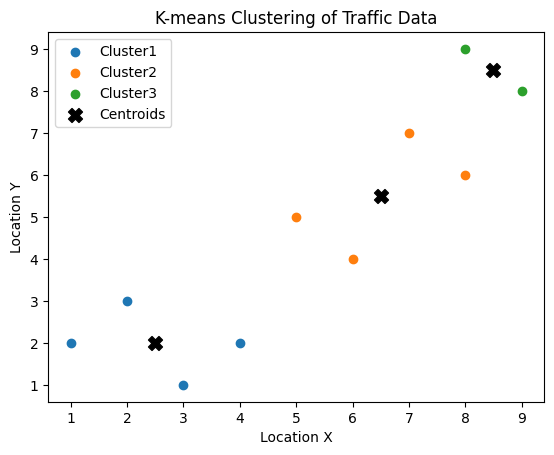

In [3]:
def visualize_traffic_clusters(X, idx, centroids):
    for k in range(K):
        cluster = X[idx == k]
        plt.scatter(cluster[:, 0], cluster[
                    :, 1], label=f"Cluster{k+1}")
    plt.scatter(centroids[:, 0], centroids[
                :, 1], color='black', marker='X', s=100, label="Centroids")
    plt.legend()
    plt.xlabel("Location X")
    plt.ylabel("Location Y")
    plt.title("K-means Clustering of Traffic Data")
    plt.savefig(image_dir / "kmeans-clustering-traffic-data.png", dpi=300, bbox_inches="tight")
    plt.show()

visualize_traffic_clusters(traffic_data, idx, centroids)

### Visualize traffic data points assigned to each cluster

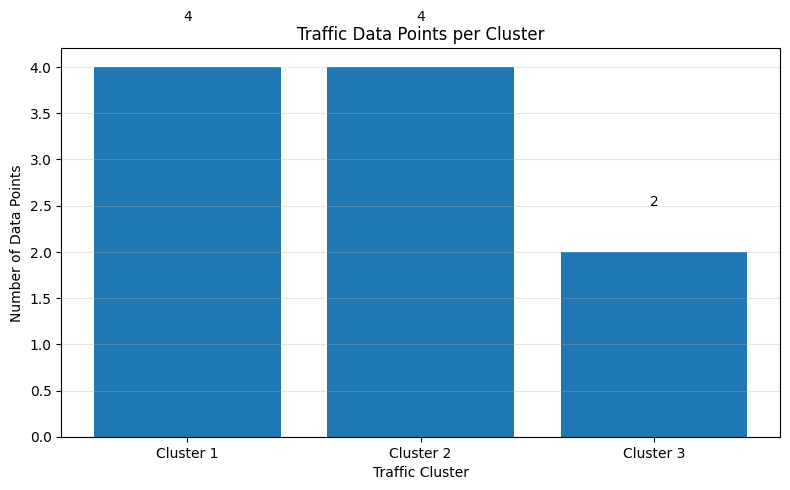

In [4]:
# Visualize the number of traffic data points assigned to each cluster

cluster_counts = np.bincount(idx, minlength=K)
cluster_labels = [f"Cluster {i + 1}" for i in range(K)]

plt.figure(figsize=(8, 5))
plt.bar(cluster_labels, cluster_counts)

for i, count in enumerate(cluster_counts):
    plt.text(i, count + 0.5, str(count), ha="center", fontsize=10)

plt.xlabel("Traffic Cluster")
plt.ylabel("Number of Data Points")
plt.title("Traffic Data Points per Cluster")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(image_dir / "traffic_cluster_size_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

The cluster size chart shows the distribution of traffic data points across the three detected traffic zones. This helps determine whether traffic patterns are evenly distributed across the city or concentrated in one or two dominant regions. A much larger cluster may indicate a high-activity zone, while smaller clusters may represent localized or less frequent traffic patterns. The K-means model produced three relatively balanced traffic clusters, suggesting that the traffic data points are distributed across multiple spatial activity zones rather than being concentrated in one dominant region.

### Evaluate different K values using the elbow method

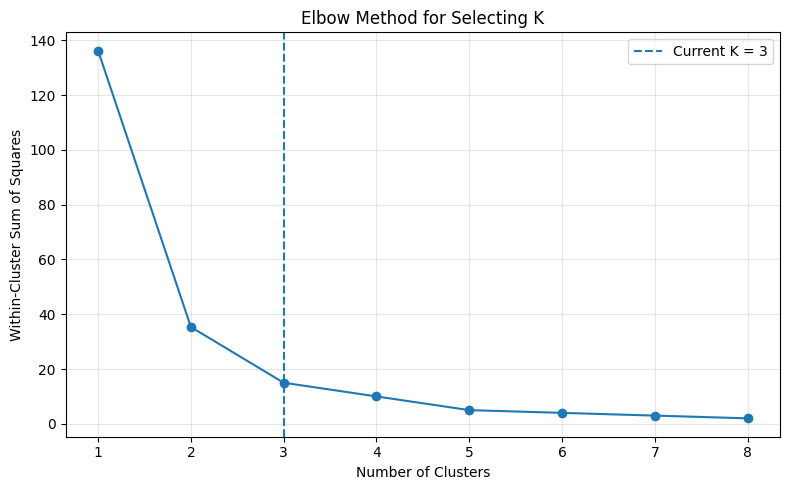

In [5]:
# Evaluate different K values using the elbow method

import warnings

def calculate_wcss(X, idx, centroids):
    wcss = 0

    for k in range(centroids.shape[0]):
        cluster_points = X[idx == k]

        if len(cluster_points) > 0:
            wcss += np.sum((cluster_points - centroids[k]) ** 2)

    return wcss


K_values = range(1, min(8, traffic_data.shape[0]) + 1)
wcss_values = []

for k in K_values:
    best_wcss = np.inf

    for seed in range(20):
        np.random.seed(seed)

        initial_centroids = initialize_centroids(traffic_data, k)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            trial_centroids, _ = run_kmeans(
                traffic_data,
                initial_centroids,
                max_iters
            )

        if np.isnan(trial_centroids).any():
            continue

        trial_idx = find_closest_centroids(traffic_data, trial_centroids)
        trial_wcss = calculate_wcss(traffic_data, trial_idx, trial_centroids)

        if trial_wcss < best_wcss:
            best_wcss = trial_wcss

    wcss_values.append(best_wcss)

plt.figure(figsize=(8, 5))
plt.plot(list(K_values), wcss_values, marker="o")
plt.axvline(x=K, linestyle="--", label=f"Current K = {K}")

plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares")
plt.title("Elbow Method for Selecting K")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(image_dir / "traffic_kmeans_elbow_curve.png", dpi=300, bbox_inches="tight")
plt.show()

The elbow curve shows a sharp reduction in within-cluster sum of squares from K = 1 to K = 3, followed by a slower rate of improvement after K = 3. This suggests that three clusters provide a reasonable balance between compactness and simplicity for the traffic data.

### Evaluate different K values using silhouette scores

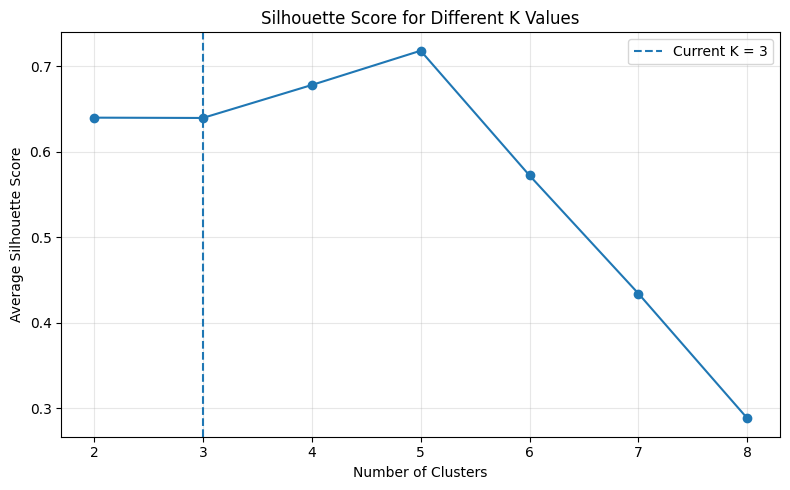

In [6]:
# Evaluate different K values using silhouette scores

def calculate_silhouette_score(X, idx):
    silhouette_values = []

    for i in range(X.shape[0]):
        same_cluster = X[idx == idx[i]]
        other_clusters = np.unique(idx[idx != idx[i]])

        if len(same_cluster) <= 1:
            silhouette_values.append(0)
            continue

        a = np.mean(np.linalg.norm(same_cluster - X[i], axis=1))

        b_values = []
        for cluster_id in other_clusters:
            other_cluster_points = X[idx == cluster_id]
            b_values.append(np.mean(np.linalg.norm(other_cluster_points - X[i], axis=1)))

        b = min(b_values)

        silhouette = (b - a) / max(a, b)
        silhouette_values.append(silhouette)

    return np.mean(silhouette_values)


K_values = range(2, min(8, traffic_data.shape[0]) + 1)
silhouette_scores = []

for k in K_values:
    best_score = -1

    for seed in range(20):
        np.random.seed(seed)

        initial_centroids = initialize_centroids(traffic_data, k)
        trial_centroids, _ = run_kmeans(
            traffic_data,
            initial_centroids,
            max_iters
        )

        if np.isnan(trial_centroids).any():
            continue

        trial_idx = find_closest_centroids(traffic_data, trial_centroids)
        trial_score = calculate_silhouette_score(traffic_data, trial_idx)

        if trial_score > best_score:
            best_score = trial_score

    silhouette_scores.append(best_score)

plt.figure(figsize=(8, 5))
plt.plot(list(K_values), silhouette_scores, marker="o")
plt.axvline(x=K, linestyle="--", label=f"Current K = {K}")

plt.xlabel("Number of Clusters")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(image_dir / "traffic_kmeans_silhouette_scores.png", dpi=300, bbox_inches="tight")
plt.show()

The silhouette score is highest at K = 5, suggesting that five clusters produce the strongest mathematical separation. However, because the traffic dataset contains only a small number of points, K = 5 would create very small micro-clusters that may be less useful for interpretation. Combined with the elbow curve, K = 3 remains a reasonable choice because it balances compactness, separation, and interpretability.

### 2. Part 2: <u>Anomaly Detection For Energy Grid Monitoring</u>

Task:  implement a Gaussian-based anomaly detection algorithm to identify these anomalies.

#### 2.1 Load Energy Data

In [7]:
# Load energy data
energy_data = pd.read_csv("../data/energy_data.csv")

X_train = energy_data[energy_data['Label'] == 0][[
    'EnergyConsumption', 'Time']].values
X_val = energy_data[['EnergyConsumption', 'Time']].values
y_val = energy_data["Label"].values

#### 2.2 Estimating Gaussian Parameters
Implement a function to estimate the parameters of the Gaussian Distribution

In [8]:
def estimate_gaussian(X):
    mu = np.mean(X, axis=0)
    var = np.var(X, axis=0)
    return mu, var

def multivariate_gaussian(X, mu, var):
    k = len(mu)
    term1 = 1 / (np.sqrt((2 * np.pi) ** k * np.prod(var)))
    term2 = np.exp(-0.5 * np.sum(((X - mu) ** 2) / var, axis=1))
    return term1 * term2

#### 2.3 Selecting the Threshold based on F1-Score
Implement a function to select the best threshold

In [9]:
def select_threshold(y_val, p_val):
    best_epsilon = 0
    best_f1 = 0

    step_size = (max(p_val) - min(p_val)) / 1000

    for epsilon in np.arange(min(p_val), max(p_val), step_size):
        predictions = p_val < epsilon

        tp = np.sum((predictions == 1) & (y_val == 1))
        fp = np.sum((predictions == 1) & (y_val == 0))
        fn = np.sum((predictions == 0) & (y_val == 1))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        if (precision + recall) > 0:
            f1 = 2 * precision * recall / (precision + recall)
        else:
            f1 = 0

        if f1 > best_f1:
            best_f1 = f1
            best_epsilon = epsilon

    return best_epsilon, best_f1

#### 2.4 Application to the Energy Data to discover Anomalies

In [10]:
# Estimate Gaussian Parameters
mu, var = estimate_gaussian(X_train)

# Calculate probabilities
p_val = multivariate_gaussian(X_val, mu, var)

# Select the best threshold
epsilon, F1 = select_threshold(energy_data['Label'].values, p_val)

# Identify anomalies
anomalies = p_val < epsilon

print("Number of anomalies found:", np.sum(anomalies))

Number of anomalies found: 3


### Visualize F-1 score changes across different anomaly thresholds

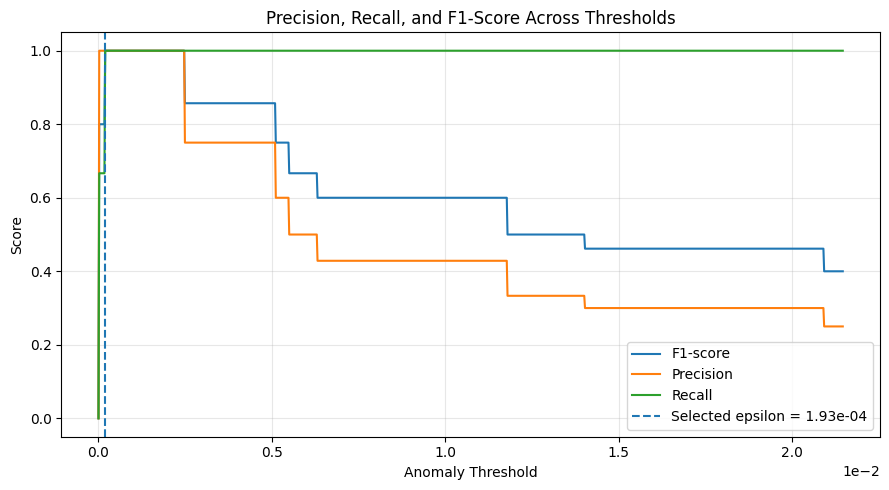

In [11]:
# Visualize how F1-score changes across different anomaly thresholds

thresholds = np.linspace(np.min(p_val), np.max(p_val), 1000)
f1_scores = []
precision_scores = []
recall_scores = []

for threshold in thresholds:
    predictions = p_val < threshold

    tp = np.sum((predictions == 1) & (y_val == 1))
    fp = np.sum((predictions == 1) & (y_val == 0))
    fn = np.sum((predictions == 0) & (y_val == 1))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    if (precision + recall) > 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = 0

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, f1_scores, label="F1-score")
plt.plot(thresholds, precision_scores, label="Precision")
plt.plot(thresholds, recall_scores, label="Recall")
plt.axvline(x=epsilon, linestyle="--", label=f"Selected epsilon = {epsilon:.2e}")

plt.xlabel("Anomaly Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1-Score Across Thresholds")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
plt.tight_layout()
plt.savefig(image_dir / "energy_threshold_performance_curve.png", dpi=300, bbox_inches="tight")
plt.show()

### Visualize Gaussian probability scores for normal and anomalous records

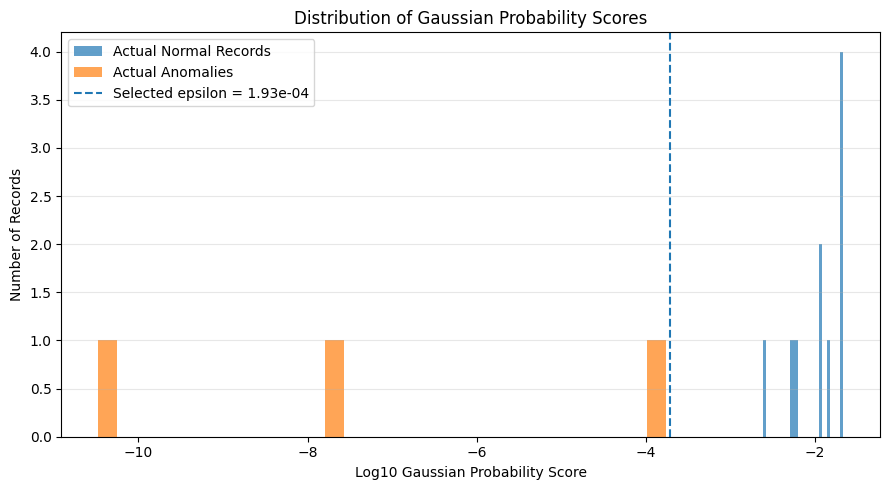

In [12]:
# Visualize Gaussian probability scores for normal and anomalous records

labels = np.asarray(y_val)

safe_p_val = np.maximum(p_val, 1e-300)
log_p_val = np.log10(safe_p_val)
log_epsilon = np.log10(max(epsilon, 1e-300))

normal_scores = log_p_val[labels == 0]
anomaly_scores = log_p_val[labels == 1]

plt.figure(figsize=(9, 5))
plt.hist(normal_scores, bins=30, alpha=0.7, label="Actual Normal Records")
plt.hist(anomaly_scores, bins=30, alpha=0.7, label="Actual Anomalies")
plt.axvline(
    x=log_epsilon,
    linestyle="--",
    label=f"Selected epsilon = {epsilon:.2e}"
)

plt.xlabel("Log10 Gaussian Probability Score")
plt.ylabel("Number of Records")
plt.title("Distribution of Gaussian Probability Scores")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(image_dir / "energy_probability_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

The probability score distribution shows clear separation between normal records and actual anomalies. The anomalous records have much lower Gaussian probability scores, while normal records appear in the higher-probability region. The selected epsilon threshold separates these groups effectively, suggesting that the Gaussian anomaly detector is making confident anomaly decisions on this dataset.

### Evaluate anomaly detection performance using a confusion matrix

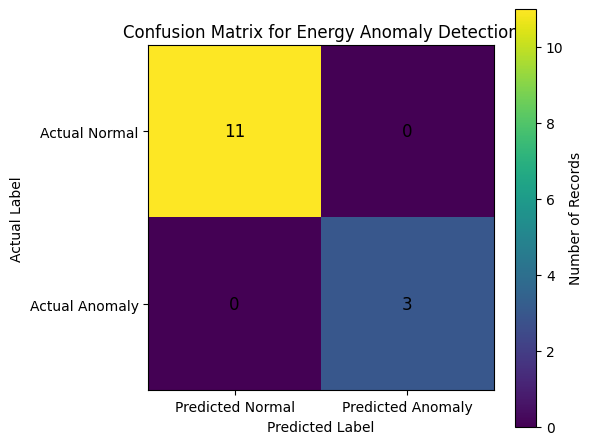

Accuracy:  1.00
Precision: 1.00
Recall:    1.00
F1-score:  1.00


In [13]:
# Evaluate anomaly detection performance using a confusion matrix

actual_labels = np.asarray(y_val)
predicted_anomalies = np.asarray(anomalies)

tn = np.sum((actual_labels == 0) & (predicted_anomalies == 0))
fp = np.sum((actual_labels == 0) & (predicted_anomalies == 1))
fn = np.sum((actual_labels == 1) & (predicted_anomalies == 0))
tp = np.sum((actual_labels == 1) & (predicted_anomalies == 1))

confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

accuracy = (tp + tn) / np.sum(confusion_matrix)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

plt.figure(figsize=(6, 5))
plt.imshow(confusion_matrix)

plt.xticks([0, 1], ["Predicted Normal", "Predicted Anomaly"])
plt.yticks([0, 1], ["Actual Normal", "Actual Anomaly"])

for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for Energy Anomaly Detection")
plt.colorbar(label="Number of Records")
plt.tight_layout()
plt.savefig(image_dir / "energy_anomaly_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-score:  {f1_score:.2f}")

The confusion matrix shows that the Gaussian anomaly detection model correctly classified all records in the validation dataset. It identified all 3 actual anomalies and correctly classified all 11 normal records, producing no false positives and no false negatives. This resulted in accuracy, precision, recall, and F1-score values of 1.00. However, because the dataset is small, these results should be interpreted as evidence that the method works well on this sample rather than proof of general performance on larger smart city energy data.

#### 2.5 Visualize Anomaly
Implement a function to visualize the anomalies within the energy grid monitoring data

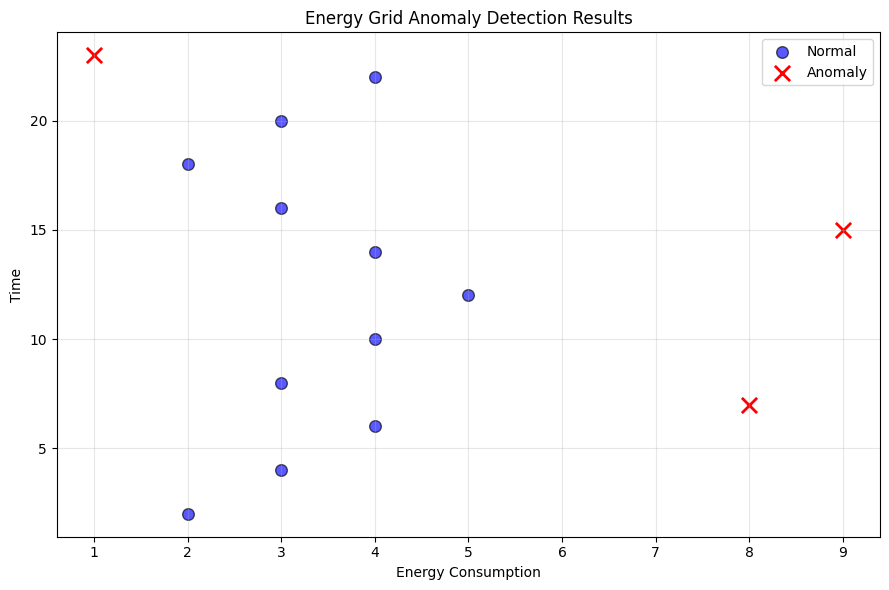

In [14]:
from pathlib import Path

def visualize_anomalies(X, anomalies_mask):
    plt.figure(figsize=(9, 6))

    plt.scatter(
        X[~anomalies_mask, 0],
        X[~anomalies_mask, 1],
        c="blue",
        label="Normal",
        alpha=0.65,
        s=70,
        edgecolor="black"
    )

    plt.scatter(
        X[anomalies_mask, 0],
        X[anomalies_mask, 1],
        c="red",
        label="Anomaly",
        marker="x",
        s=120,
        linewidths=2
    )

    plt.xlabel("Energy Consumption")
    plt.ylabel("Time")
    plt.title("Energy Grid Anomaly Detection Results")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(image_dir / "energy_grid_anomaly_detection.png", dpi=300, bbox_inches="tight")
    plt.show()

visualize_anomalies(X_val, anomalies)

### 3. <u>Clustering and Anomaly Detection Analysis</u>

In the first part of the smart city management implementation, a K-means clustering algorithm was applied to traffic data to understand spatial patterns in vehicle movement or congestion levels across different locations within the smart city. The clustering output, visualized with distinct color-coded clusters and bold black centroids, shows three well-defined groups of data points. Each cluster likely corresponds to zones with similar traffic density or flow characteristics — for instance, high-traffic zones, moderate areas, and low-density segments. The centroids represent the average location of activity within each group and can be interpreted as central hubs of traffic activity or control points for monitoring.

Complementing this, an anomaly detection model was applied to sensor data from Technopolis' energy grid to detect possible anomalies causing the inefficiencies in the energy grid. Using a multivariate Gaussian distribution, the system learned the normal behavior of the grid by analyzing the statistical patterns in historical readings. The resulting scatter plot clearly distinguished normal operating conditions from anomalies. Most data points clustered in a tight, central region of the plot representing stable, expected behavior. In contrast, the anomalies, marked with red Xs, were isolated and fell well outside the cluster, suggesting abnormal or potentially hazardous conditions such as equipment malfunctions, voltage spikes, or external disturbances. The model successfully identified these deviations by computing probability densities and applying a threshold optimized using the F1 score. This early detection of anomalies enhances the reliability and resilience of the energy grid, allowing operators to act proactively before faults escalate.